# Part 3 – Adversarial Attacks: Breaking the Classifier

## 1. Imports

In [1]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SEED      = 42
THRESHOLD = 0.4
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device: {DEVICE}')

Device: cuda


## 2. Load data and model

In [2]:
df_eval = pd.read_csv('eval_set.csv')
probs   = np.load('eval_probs.npy')
df_eval['pred_prob']  = probs
df_eval['pred_label'] = (probs >= THRESHOLD).astype(int)

MODEL_DIR = './baseline_model'
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

def load_model(model_dir):
    m = AutoModelForSequenceClassification.from_pretrained(model_dir)
    m.to(DEVICE)
    m.eval()
    return m

baseline_model = load_model(MODEL_DIR)
print('Baseline model loaded.')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 502.79it/s]


Baseline model loaded.


In [3]:
def predict_proba_batch(texts: list, model, tok, batch_size=64) -> np.ndarray:
    """Return P(toxic) for each text."""
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = tok(batch, padding=True, truncation=True,
                    max_length=128, return_tensors='pt')
        enc   = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[:, 1]
        all_probs.extend(probs)
    return np.array(all_probs)

---
# Attack 1 – Character-level Evasion

### 2.1 The `perturb()` function

In [4]:
# Unicode homoglyph map: Latin char -> visually identical Cyrillic/lookalike
HOMOGLYPHS = {
    'a': '\u0430',  # Cyrillic а
    'e': '\u0435',  # Cyrillic е
    'o': '\u043e',  # Cyrillic о
    'p': '\u0440',  # Cyrillic р
    'c': '\u0441',  # Cyrillic с
    'x': '\u0445',  # Cyrillic х
    'i': '\u0456',  # Cyrillic і (Ukrainian)
    's': '\u0455',  # Cyrillic ѕ
}

ZERO_WIDTH_SPACE = '\u200B'


def _insert_zero_width(word: str) -> str:
    """Insert zero-width space between every 2-3 chars of the word."""
    step   = random.choice([2, 3])
    result = ''
    for i, ch in enumerate(word):
        result += ch
        if (i + 1) % step == 0 and (i + 1) < len(word):
            result += ZERO_WIDTH_SPACE
    return result


def _homoglyph_substitute(word: str) -> str:
    """Replace Latin chars with Cyrillic lookalikes."""
    return ''.join(HOMOGLYPHS.get(ch.lower(), ch) for ch in word)


def _random_duplicate(word: str, rate: float = 0.2) -> str:
    """For each char, with probability `rate`, insert a duplicate."""
    result = ''
    for ch in word:
        result += ch
        if random.random() < rate:
            result += ch
    return result


def perturb(text: str) -> str:
    """
    Apply three character-level perturbations to the input text:
    1. Zero-width space insertion
    2. Unicode homoglyph substitution
    3. Random character duplication (20% per character)
    """
    words = text.split()
    perturbed = []
    for word in words:
        w = _insert_zero_width(word)
        w = _homoglyph_substitute(w)
        w = _random_duplicate(w, rate=0.2)
        perturbed.append(w)
    return ' '.join(perturbed)


# Quick demo
sample_text = "You are a disgusting hateful person and you should be ashamed"
print('Original  :', sample_text)
print('Perturbed :', perturb(sample_text))

Original  : You are a disgusting hateful person and you should be ashamed
Perturbed : YYо​u аrr​​е а dіѕ​​guѕ​​tіnn​​g hаt​еfu​l рее​rѕѕ​ооn ааnd yоо​uu ѕhо​uldd bе аѕ​hа​mе​d


### 2.2 Evaluate Attack Success Rate

In [5]:
# Select 500 comments that the clean model predicts as toxic with high confidence
high_conf_toxic = df_eval[
    (df_eval['pred_label'] == 1) & (df_eval['pred_prob'] >= 0.7)
].sample(n=min(500, len(df_eval[(df_eval['pred_label']==1)&(df_eval['pred_prob']>=0.7)])),
         random_state=SEED)

print(f'Selected {len(high_conf_toxic)} high-confidence toxic comments.')

# Apply perturbation
original_texts   = list(high_conf_toxic['comment_text'])
perturbed_texts  = [perturb(t) for t in original_texts]

print('Running model on original texts …')
probs_original   = predict_proba_batch(original_texts,  baseline_model, tokenizer)

print('Running model on perturbed texts …')
probs_perturbed  = predict_proba_batch(perturbed_texts, baseline_model, tokenizer)

preds_original   = (probs_original  >= THRESHOLD).astype(int)
preds_perturbed  = (probs_perturbed >= THRESHOLD).astype(int)

# Attack success: originally detected (1), now undetected (0)
asr = np.mean((preds_original == 1) & (preds_perturbed == 0))

print('\n=== Attack 1: Character-Level Evasion Results ===')
print(f'  N sample          : {len(high_conf_toxic)}')
print(f'  Attack Success Rate (ASR) : {asr:.4f} ({asr*100:.1f}%)')
print(f'  Avg confidence BEFORE perturbation: {probs_original.mean():.4f}')
print(f'  Avg confidence AFTER  perturbation: {probs_perturbed.mean():.4f}')
print(f'  Confidence drop   : {probs_original.mean() - probs_perturbed.mean():.4f}')

Selected 500 high-confidence toxic comments.
Running model on original texts …
Running model on perturbed texts …

=== Attack 1: Character-Level Evasion Results ===
  N sample          : 500
  Attack Success Rate (ASR) : 0.9980 (99.8%)
  Avg confidence BEFORE perturbation: 0.9139
  Avg confidence AFTER  perturbation: 0.0151
  Confidence drop   : 0.8988


                   Metric          Value
                N sampled            500
Attack Success Rate (ASR) 0.9980 (99.8%)
  Avg confidence (before)         0.9139
   Avg confidence (after)         0.0151
          Confidence drop         0.8988


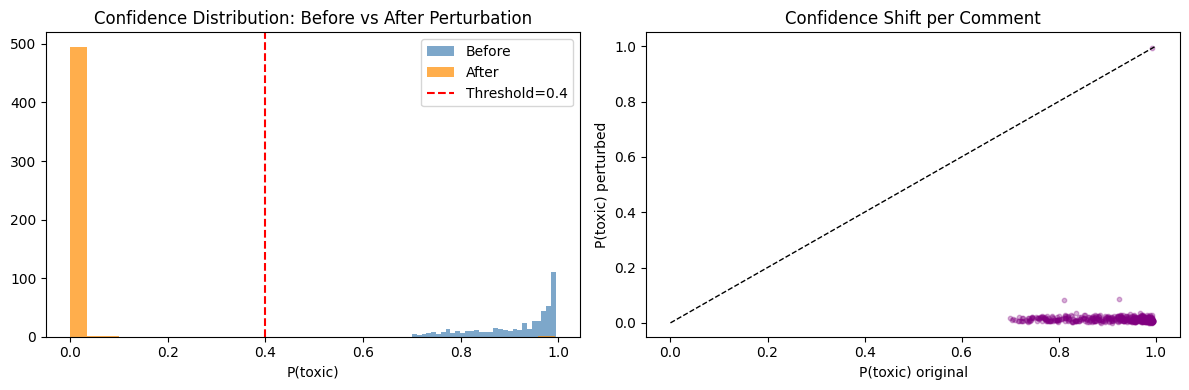

In [6]:
# ASR summary table
asr_table = pd.DataFrame({
    'Metric': ['N sampled', 'Attack Success Rate (ASR)',
               'Avg confidence (before)', 'Avg confidence (after)', 'Confidence drop'],
    'Value': [
        len(high_conf_toxic),
        f'{asr:.4f} ({asr*100:.1f}%)',
        f'{probs_original.mean():.4f}',
        f'{probs_perturbed.mean():.4f}',
        f'{probs_original.mean()-probs_perturbed.mean():.4f}',
    ]
})
print(asr_table.to_string(index=False))

# Visualise confidence shift
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(probs_original,  bins=30, color='steelblue', alpha=0.7, label='Before')
axes[0].hist(probs_perturbed, bins=30, color='darkorange', alpha=0.7, label='After')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[0].set_title('Confidence Distribution: Before vs After Perturbation')
axes[0].set_xlabel('P(toxic)')
axes[0].legend()

axes[1].scatter(probs_original, probs_perturbed, alpha=0.3, s=10, color='purple')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('P(toxic) original')
axes[1].set_ylabel('P(toxic) perturbed')
axes[1].set_title('Confidence Shift per Comment')

plt.tight_layout()
plt.show()

---
# Attack 2 – Label-Flipping Poisoning

### 3.1 Poison the training data

In [7]:
from sklearn.model_selection import train_test_split

DATA_PATH   = 'jigsaw-unintended-bias-train.csv'
COLS_NEEDED = ['comment_text', 'toxic', 'black', 'white']

df_full = pd.read_csv(DATA_PATH, usecols=COLS_NEEDED)
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)

df_train_clean, _ = train_test_split(
    df_full, train_size=100_000, stratify=df_full['label'], random_state=SEED
)
df_train_clean = df_train_clean.reset_index(drop=True)

# Poison: flip 5% of labels randomly
n_poison = int(0.05 * len(df_train_clean))
poison_idx = np.random.choice(len(df_train_clean), size=n_poison, replace=False)

df_train_poisoned = df_train_clean.copy()
df_train_poisoned.loc[poison_idx, 'label'] = 1 - df_train_poisoned.loc[poison_idx, 'label']

print(f'Training set size  : {len(df_train_poisoned)}')
print(f'Labels flipped     : {n_poison} ({n_poison/len(df_train_poisoned)*100:.1f}%)')
print(f'Clean toxic rate   : {df_train_clean["label"].mean():.3f}')
print(f'Poisoned toxic rate: {df_train_poisoned["label"].mean():.3f}')

Training set size  : 100000
Labels flipped     : 5000 (5.0%)
Clean toxic rate   : 0.080
Poisoned toxic rate: 0.121


### 3.2 Retrain on poisoned data

In [8]:
class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len=128):
        self.enc = tok(
            list(texts), padding='max_length', truncation=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

# Reload eval dataset
df_eval = pd.read_csv('eval_set.csv')

print('Tokenising poisoned training set …')
poisoned_train_ds = JigsawDataset(df_train_poisoned['comment_text'],
                                   df_train_poisoned['label'], tokenizer)
print('Tokenising evaluation set …')
eval_ds = JigsawDataset(df_eval['comment_text'], df_eval['label'], tokenizer)
print('Done.')

Tokenising poisoned training set …
Tokenising evaluation set …
Done.


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    fnr   = np.sum((preds==0) & (labels==1)) / max(np.sum(labels==1), 1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='macro'),
        'auc':      roc_auc_score(labels, probs),
        'fnr':      fnr,
    }

# Retrain from original distilbert-base-uncased (not from Part 1 checkpoint)
poisoned_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)

poison_args = TrainingArguments(
    output_dir               = './poisoned_model',
    num_train_epochs         = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio             = 0.1,
    weight_decay             = 0.01,
    learning_rate            = 2e-5,
    eval_strategy            = 'epoch',
    save_strategy            = 'no',
    fp16                     = (DEVICE == 'cuda'),
    logging_steps            = 200,
    report_to                = 'none',
    seed                     = SEED,
)


poison_trainer = Trainer(
    model           = poisoned_model,
    args            = poison_args,
    train_dataset   = poisoned_train_ds,
    eval_dataset    = eval_ds,
    compute_metrics = compute_metrics,
)

print('Training poisoned model (3 epochs) …')
poison_trainer.train()
print('Done.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7391.37it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training poisoned model (3 epochs) …


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc,Fnr
1,0.284298,0.158977,0.951250,0.834551,0.950503,0.304185
2,0.270391,0.131260,0.961800,0.872210,0.965644,0.222361
3,0.229962,0.118205,0.967800,0.888522,0.963829,0.222361


Done.


### 3.3 Before vs after comparison

In [11]:
# Baseline metrics (from Part 1)
probs_baseline = np.load('eval_probs.npy')
true_labels    = df_eval['label'].values
preds_baseline = (probs_baseline >= THRESHOLD).astype(int)

fnr_baseline = np.sum((preds_baseline==0) & (true_labels==1)) / max(true_labels.sum(), 1)

# Poisoned model metrics
poison_preds = poison_trainer.predict(eval_ds)
probs_poison = torch.softmax(torch.tensor(poison_preds.predictions), dim=-1).numpy()[:, 1]
preds_poison = (probs_poison >= THRESHOLD).astype(int)

fnr_poison = np.sum((preds_poison==0) & (true_labels==1)) / max(true_labels.sum(), 1)

comparison = pd.DataFrame({
    'Model'   : ['Baseline (clean data)', 'Poisoned (5% label flip)'],
    'Accuracy': [
        round(accuracy_score(true_labels, preds_baseline), 4),
        round(accuracy_score(true_labels, preds_poison),   4),
    ],
    'F1 (macro)': [
        round(f1_score(true_labels, preds_baseline, average='macro'), 4),
        round(f1_score(true_labels, preds_poison,   average='macro'), 4),
    ],
    'FNR': [
        round(fnr_baseline, 4),
        round(fnr_poison,   4),
    ],
    'AUC-ROC': [
        round(roc_auc_score(true_labels, probs_baseline), 4),
        round(roc_auc_score(true_labels, probs_poison),   4),
    ],
})
print('=== Attack 2: Label-Flipping Poisoning – Before/After ===')
print(comparison.to_string(index=False))

=== Attack 2: Label-Flipping Poisoning – Before/After ===
                   Model  Accuracy  F1 (macro)    FNR  AUC-ROC
   Baseline (clean data)    0.9432      0.8148 0.3092   0.9461
Poisoned (5% label flip)    0.9678      0.8885 0.2224   0.9638


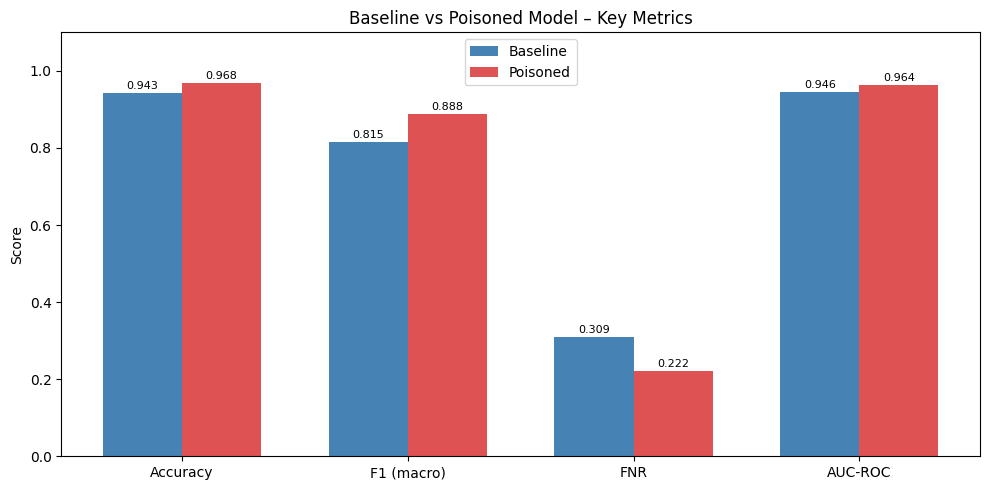

In [12]:
# Bar chart: metric deltas
metrics_to_plot = ['Accuracy', 'F1 (macro)', 'FNR', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
baseline_vals = comparison[comparison['Model'].str.contains('Baseline')][metrics_to_plot].values[0]
poison_vals   = comparison[comparison['Model'].str.contains('Poisoned')][metrics_to_plot].values[0]

ax.bar(x - width/2, baseline_vals, width, label='Baseline',  color='steelblue')
ax.bar(x + width/2, poison_vals,   width, label='Poisoned',  color='#d62728', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Poisoned Model – Key Metrics')
ax.legend()
ax.set_ylim(0, 1.1)

for i, (b, p) in enumerate(zip(baseline_vals, poison_vals)):
    ax.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, p + 0.01, f'{p:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Analysis: Which attack is more dangerous?

### Operational threat assessment

| Dimension | Evasion (Attack 1) | Poisoning (Attack 2) |
|---|---|---|
| **Attacker access required** | Only inference API (zero-knowledge) | Write access to training pipeline / data store |
| **Per-comment effort** | High — must perturb each message individually | One-time: flip labels before training |
| **Scalability** | Limited — manual or scripted per post | Fully automated; scales to millions of rows |
| **Detectability** | Perturbed text is detectable via Unicode normalisation | Poisoned labels look like labelling errors |
| **Damage type** | Individual toxic posts slip through | Systematic degradation of all future decisions |
| **FNR impact** | Moderate (selected posts evade) | High — FNR rises globally |

### Contrast

The evasion attack is more operationally realistic and immediately dangerous for a live social platform. Most adversarial users on social media have only inference access — they can see whether their post gets removed and iterate. A motivated bad actor (e.g. someone running a harassment campaign) can write a browser extension that auto-perturbs text before submission. The attack requires no special access and produces near-human-readable output.

The poisoning attack, while theoretically devastating (it corrupts the model itself), requires supply-chain access to training data — a much higher bar. It is more relevant as an insider threat or as an attack on a crowd-sourced annotation pipeline. Real-world examples exist but require either insider access or ability to inject large volumes of training data.

### Defence priorities

1. **Evasion** → Unicode normalisation (NFKC) as a preprocessing step; subword-robustness training; character-CNN auxiliary models that are invariant to homoglyph substitution.
2. **Poisoning** → Cryptographic signing of training data batches; anomaly detection on label distributions; differential privacy during training to limit per-example influence.